# 03 - KnottedGraph vs Topoly Scaling

This notebook runs two theorem-backed validation and timing suites. Dobrynin-Vesnin tests the canonical `Theta(n)` family against the published Theorem 2 formula. Li-Lei-Li-Vesnin tests edge-replaced `C_n`, `Theta_s`, and `B_q` families against Theorem 5.1, where the theorem is used only as a post-computation oracle.

Dobrynin-Vesnin rows are saved after each completed `n`. Li-Lei-Li-Vesnin rows are saved after each completed `C_n`, `Theta_s`, or `B_q`.

The CSV written by this notebook is both the resume ledger and the reusable result table. If the notebook is interrupted, rerun the cells: completed rows for the current settings are reused and missing rows continue. Each row records KnottedGraph and Topoly timings, pass/error status, and the time spent even for nonpassing or error cases. Passing plotted points use `.` markers; nonpassing, error, timeout, or skipped points use `x` markers.


In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import contextlib
import csv
import hashlib
import io
import json
import os
import sys
import time

from tqdm.auto import tqdm

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError(
        "Could not locate the KnottedGraph repository root. "
        "Run this notebook from inside the repository checkout."
    )

DEV = ROOT / "dev"
if str(DEV) not in sys.path:
    sys.path.insert(0, str(DEV))

RESULT_SCHEMA_VERSION = 4
RESULTS_DIR = ROOT / "User_guide" / "benchmarks" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = RESULTS_DIR / "03_knottedgraph_vs_topoly_scaling_rows.csv"

RESUME_FROM_CSV = True
RESET_CURRENT_RESULTS = False
SHOW_INTERNAL_JSON_LOGS = False

PREFERRED_COLUMNS = [
    "settings_hash",
    "schema_version",
    "benchmark",
    "suite",
    "case_key",
    "graph_type",
    "size",
    "label",
    "family",
    "n",
    "abstract_graph",
    "V",
    "E",
    "crossings",
    "extra_projection_crossings",
    "knottedgraph_result",
    "knottedgraph_status",
    "knottedgraph_s",
    "topoly_result",
    "topoly_status",
    "topoly_s",
    "topoly_over_knottedgraph",
    "case_wall_s",
    "timeout_s",
    "row_error",
    "knottedgraph_error",
    "topoly_error",
    "paper",
    "theorem",
    "formula",
    "pieces",
    "case_hash",
    "embedding_hash",
    "pd_hash",
]


def _settings_hash(payload):
    encoded = json.dumps(payload, sort_keys=True, default=str).encode()
    return hashlib.sha256(encoded).hexdigest()[:12]


def _csv_cell(value):
    if value is None:
        return ""
    if isinstance(value, (list, tuple, dict)):
        return json.dumps(value, sort_keys=True, default=str)
    return value


def _read_result_csv(path=RESULTS_CSV):
    if not path.exists():
        return []
    with path.open("r", encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))


def _write_result_csv(rows, path=RESULTS_CSV):
    path.parent.mkdir(parents=True, exist_ok=True)
    extra = sorted({key for row in rows for key in row if key not in PREFERRED_COLUMNS})
    columns = PREFERRED_COLUMNS + extra
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=columns, extrasaction="ignore")
        writer.writeheader()
        for row in rows:
            writer.writerow({key: _csv_cell(row.get(key)) for key in columns})
        handle.flush()
        os.fsync(handle.fileno())
    tmp.replace(path)


def _replace_result_row(rows, row):
    key = (str(row["settings_hash"]), str(row["case_key"]))
    kept = [
        old for old in rows
        if (str(old.get("settings_hash")), str(old.get("case_key"))) != key
    ]
    kept.append(row)
    _write_result_csv(kept)
    return kept


def _as_float(value):
    if value in (None, ""):
        return None
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def _format_seconds(value):
    value = _as_float(value)
    return "" if value is None else f"{value:.4g}s"


def _kg_result(row):
    return row.get("knottedgraph_result") or row.get("knottedgraph_vs_published") or row.get("knottedgraph_vs_theorem") or ""


def _topoly_result(row):
    return row.get("topoly_result") or row.get("topoly_vs_published") or row.get("topoly_vs_theorem") or ""


def _print_case_status(row, *, reused=False):
    prefix = "reuse" if reused else "saved"
    print(
        f"{prefix:5s} {row.get('case_key', row.get('label', 'case'))}: "
        f"KG {_format_seconds(row.get('knottedgraph_s')) or 'n/a'} {_kg_result(row) or row.get('knottedgraph_status', '')}; "
        f"Topoly {_format_seconds(row.get('topoly_s')) or 'n/a'} {_topoly_result(row) or row.get('topoly_status', '')}"
    )


def _run_and_capture(run_one):
    if SHOW_INTERNAL_JSON_LOGS:
        return run_one()
    buffer = io.StringIO()
    try:
        with contextlib.redirect_stdout(buffer):
            return run_one()
    except Exception:
        captured = buffer.getvalue().strip()
        if captured:
            print(captured)
        raise


def _normalise_dv_row(raw, *, settings_hash, timeout_s):
    row = dict(raw)
    n = int(row["n"])
    row.update(
        {
            "settings_hash": settings_hash,
            "schema_version": RESULT_SCHEMA_VERSION,
            "benchmark": "dobrynin_vesnin_theta_validation",
            "suite": "Dobrynin-Vesnin Theta(n)",
            "case_key": f"dv:theta:{n}",
            "graph_type": f"dv_{row.get('abstract_graph', 'theta')}",
            "size": n,
            "label": f"Theta({n})",
            "timeout_s": timeout_s,
            "knottedgraph_result": row.get("knottedgraph_vs_published", ""),
            "topoly_result": row.get("topoly_vs_published", ""),
        }
    )
    return row


def _normalise_lllv_row(raw, *, settings_hash, timeout_s):
    row = dict(raw)
    pieces = row.get("pieces", [])
    row.update(
        {
            "settings_hash": settings_hash,
            "schema_version": RESULT_SCHEMA_VERSION,
            "benchmark": "li_lei_li_vesnin_edge_replacement_validation",
            "suite": "Li-Lei-Li-Vesnin edge replacement",
            "case_key": f"lllv:{row['family']}:{row['label']}",
            "graph_type": row["family"],
            "size": len(pieces),
            "timeout_s": timeout_s,
            "knottedgraph_result": row.get("knottedgraph_vs_theorem", ""),
            "topoly_result": row.get("topoly_vs_theorem", ""),
        }
    )
    return row


def _error_row(*, settings_hash, benchmark, suite, case_key, graph_type, size, label, timeout_s, elapsed_s, exc):
    return {
        "settings_hash": settings_hash,
        "schema_version": RESULT_SCHEMA_VERSION,
        "benchmark": benchmark,
        "suite": suite,
        "case_key": case_key,
        "graph_type": graph_type,
        "size": size,
        "label": label,
        "timeout_s": timeout_s,
        "case_wall_s": elapsed_s,
        "knottedgraph_result": "ERROR",
        "topoly_result": "ERROR",
        "row_error": f"{type(exc).__name__}: {exc}",
    }


def _run_cases_to_csv(cases, *, settings_hash, run_case, case_key, normalise_row, error_row, desc):
    rows = _read_result_csv()
    if RESET_CURRENT_RESULTS:
        rows = [row for row in rows if str(row.get("settings_hash")) != str(settings_hash)]
        _write_result_csv(rows)
    existing = {
        str(row.get("case_key")): row
        for row in rows
        if str(row.get("settings_hash")) == str(settings_hash)
    }
    output = []
    print(f"CSV: {RESULTS_CSV}")
    print(f"Reusing {sum(str(case_key(case)) in existing for case in cases)}/{len(cases)} completed rows for {desc}")
    for case in tqdm(cases, desc=desc):
        key = str(case_key(case))
        if RESUME_FROM_CSV and key in existing:
            row = existing[key]
            _print_case_status(row, reused=True)
            output.append(row)
            continue
        start = time.perf_counter()
        try:
            raw = _run_and_capture(lambda case=case: run_case(case))
            row = normalise_row(raw)
        except Exception as exc:
            row = error_row(case, time.perf_counter() - start, exc)
        row["case_wall_s"] = time.perf_counter() - start
        rows = _replace_result_row(rows, row)
        existing[key] = row
        output.append(row)
        _print_case_status(row, reused=False)
    return output

import knotted_graph
from knotted_graph.invariants.yamada.native import native_available, native_import_error

print("Python executable:", sys.executable)
print("KnottedGraph:", Path(knotted_graph.__file__).resolve())
print("Native Yamada backend:", native_available())
print("Native import error:", native_import_error())
print("Results CSV:", RESULTS_CSV)
if not native_available():
    raise RuntimeError(
        "This benchmark requires the compiled native Yamada backend. "
        "Install the checkout with `python -m pip install -e .` in the active environment."
    )

try:
    import topoly
except ImportError as exc:
    raise ImportError("Install benchmark dependencies with: python -m pip install -e '.[benchmark]'") from exc
print("Topoly:", Path(topoly.__file__).resolve())


Python executable: /Users/hakanakgun/.venvs/nh-kg/bin/python
KnottedGraph: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/src/knotted_graph/__init__.py
Native Yamada backend: True
Native import error: None
Results CSV: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/results/03_knottedgraph_vs_topoly_scaling_rows.csv
Topoly: /Users/hakanakgun/.venvs/nh-kg/lib/python3.13/site-packages/topoly/__init__.py


In [3]:
# Input selection. Edit these lists to control the extent of each infinite family.
THETA_N_VALUES = list(range(0, 30))+[50,100,200,300,400,500]
THETA_TIMEOUT_S = 1000.0

LLLV_CYCLE_N_VALUES = list(range(3, 30))+[50,100,200,300,400,500]
LLLV_THETA_S_VALUES = list(range(3, 30))+[50,100,200,300,400,500]
LLLV_BOUQUET_Q_VALUES = list(range(3, 10))

LLLV_CYCLE_PATTERN = ("edge", "loop_bead", "theta_bead")
LLLV_THETA_PATTERN = ("edge", "loop_bead", "theta_bead")
LLLV_BOUQUET_PATTERN = ("edge",)
LLLV_TIMEOUT_S = 60.0

RUN_DOBRYNIN_VESNIN = True
RUN_LI_LEI_LI_VESNIN = True

assert all(n >= 0 for n in THETA_N_VALUES)
assert all(n >= 3 for n in LLLV_CYCLE_N_VALUES)
assert all(s >= 2 for s in LLLV_THETA_S_VALUES)
assert all(q >= 1 for q in LLLV_BOUQUET_Q_VALUES)

print("Dobrynin-Vesnin Theta(n) values:", THETA_N_VALUES)
print("Cycle C_n values:", LLLV_CYCLE_N_VALUES)
print("Theta_s values:", LLLV_THETA_S_VALUES)
print("Bouquet B_q values:", LLLV_BOUQUET_Q_VALUES)
print("Results CSV:", RESULTS_CSV)


Dobrynin-Vesnin Theta(n) values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 50, 100, 200, 300, 400, 500]
Cycle C_n values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 50, 100, 200, 300, 400, 500]
Theta_s values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 50, 100, 200, 300, 400, 500]
Bouquet B_q values: [3, 4, 5, 6, 7, 8, 9]
Results CSV: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/results/03_knottedgraph_vs_topoly_scaling_rows.csv


In [4]:
from benchmark_dobrynin_vesnin_theta_family import (
    PAPER as DV_PAPER,
    FORMULA as DV_FORMULA,
    compare_one as compare_dv_theta,
)
from benchmark_lllv_edge_replacement import (
    PAPER as LLLV_PAPER,
    build_family_cases as build_lllv_family_cases,
    compare_case as compare_lllv_case,
)

all_result_rows = []

if RUN_DOBRYNIN_VESNIN:
    dv_settings_hash = _settings_hash(
        {
            "schema_version": RESULT_SCHEMA_VERSION,
            "benchmark": "dobrynin_vesnin_theta_validation",
            "timeout_s": THETA_TIMEOUT_S,
        }
    )
    dv_rows = _run_cases_to_csv(
        list(THETA_N_VALUES),
        settings_hash=dv_settings_hash,
        run_case=lambda n: compare_dv_theta(n, THETA_TIMEOUT_S, strict=False),
        case_key=lambda n: f"dv:theta:{int(n)}",
        normalise_row=lambda raw: _normalise_dv_row(raw, settings_hash=dv_settings_hash, timeout_s=THETA_TIMEOUT_S),
        error_row=lambda n, elapsed, exc: _error_row(
            settings_hash=dv_settings_hash,
            benchmark="dobrynin_vesnin_theta_validation",
            suite="Dobrynin-Vesnin Theta(n)",
            case_key=f"dv:theta:{int(n)}",
            graph_type="dv_theta",
            size=int(n),
            label=f"Theta({int(n)})",
            timeout_s=THETA_TIMEOUT_S,
            elapsed_s=elapsed,
            exc=exc,
        ),
        desc="Dobrynin-Vesnin Theta(n)",
    )
    all_result_rows.extend(dv_rows)
else:
    dv_settings_hash = None
    dv_rows = []

if RUN_LI_LEI_LI_VESNIN:
    lllv_cases = build_lllv_family_cases(
        cycle_n_values=LLLV_CYCLE_N_VALUES,
        theta_s_values=LLLV_THETA_S_VALUES,
        bouquet_q_values=LLLV_BOUQUET_Q_VALUES,
        cycle_pattern=LLLV_CYCLE_PATTERN,
        theta_pattern=LLLV_THETA_PATTERN,
        bouquet_pattern=LLLV_BOUQUET_PATTERN,
    )
    lllv_settings_hash = _settings_hash(
        {
            "schema_version": RESULT_SCHEMA_VERSION,
            "benchmark": "li_lei_li_vesnin_edge_replacement_validation",
            "cycle_pattern": list(LLLV_CYCLE_PATTERN),
            "theta_pattern": list(LLLV_THETA_PATTERN),
            "bouquet_pattern": list(LLLV_BOUQUET_PATTERN),
            "timeout_s": LLLV_TIMEOUT_S,
        }
    )
    lllv_rows = _run_cases_to_csv(
        lllv_cases,
        settings_hash=lllv_settings_hash,
        run_case=lambda case: compare_lllv_case(case, LLLV_TIMEOUT_S, strict=False),
        case_key=lambda case: f"lllv:{case.family}:{case.label}",
        normalise_row=lambda raw: _normalise_lllv_row(raw, settings_hash=lllv_settings_hash, timeout_s=LLLV_TIMEOUT_S),
        error_row=lambda case, elapsed, exc: _error_row(
            settings_hash=lllv_settings_hash,
            benchmark="li_lei_li_vesnin_edge_replacement_validation",
            suite="Li-Lei-Li-Vesnin edge replacement",
            case_key=f"lllv:{case.family}:{case.label}",
            graph_type=case.family,
            size=len(case.pieces),
            label=case.label,
            timeout_s=LLLV_TIMEOUT_S,
            elapsed_s=elapsed,
            exc=exc,
        ),
        desc="Li-Lei-Li-Vesnin edge replacements",
    )
    all_result_rows.extend(lllv_rows)
else:
    lllv_settings_hash = None
    lllv_rows = []

print(f"Saved/reused {len(all_result_rows)} current rows")
print("CSV:", RESULTS_CSV)

summary_cols = [
    "suite",
    "graph_type",
    "size",
    "label",
    "knottedgraph_s",
    "knottedgraph_result",
    "topoly_s",
    "topoly_result",
]
print("\t".join(summary_cols))
for row in all_result_rows:
    print("\t".join(str(row.get(col, "")) for col in summary_cols))


CSV: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/results/03_knottedgraph_vs_topoly_scaling_rows.csv
Reusing 11/36 completed rows for Dobrynin-Vesnin Theta(n)


Dobrynin-Vesnin Theta(n):   0%|          | 0/36 [00:00<?, ?it/s]

reuse dv:theta:0: KG 0.001375s PASS; Topoly 0.8679s PASS
reuse dv:theta:1: KG 0.02181s PASS; Topoly 0.5984s PASS
reuse dv:theta:2: KG 0.01847s PASS; Topoly 0.5788s PASS
reuse dv:theta:3: KG 0.018s PASS; Topoly 0.5931s PASS
reuse dv:theta:4: KG 0.01808s PASS; Topoly 0.6332s PASS
reuse dv:theta:5: KG 0.01907s PASS; Topoly 0.5769s PASS
reuse dv:theta:6: KG 0.02186s PASS; Topoly 0.592s PASS
reuse dv:theta:7: KG 0.03293s PASS; Topoly 0.7408s PASS
reuse dv:theta:8: KG 0.02329s PASS; Topoly 0.6187s PASS
reuse dv:theta:9: KG 0.02437s PASS; Topoly 0.8594s PASS
reuse dv:theta:10: KG 0.03089s PASS; Topoly 1.09s PASS
saved dv:theta:11: KG 0.02998s PASS; Topoly 1s PASS
saved dv:theta:12: KG 0.02234s PASS; Topoly 0.8988s PASS
saved dv:theta:13: KG 0.02512s PASS; Topoly 0.9224s PASS
saved dv:theta:14: KG 0.03241s PASS; Topoly 0.9793s PASS
saved dv:theta:15: KG 0.02865s PASS; Topoly 1.164s PASS
saved dv:theta:16: KG 0.03405s PASS; Topoly 1.557s PASS
saved dv:theta:17: KG 0.05411s PASS; Topoly 1.545s F

Li-Lei-Li-Vesnin edge replacements:   0%|          | 0/73 [00:00<?, ?it/s]

reuse lllv:cycle:C3_edge_loop_bead_theta_bead: KG 0.01549s PASS; Topoly 0.6037s PASS
reuse lllv:cycle:C4_edge_loop_bead_theta_bead: KG 0.01475s PASS; Topoly 0.5532s ERROR
reuse lllv:cycle:C5_edge_loop_bead_theta_bead: KG 0.01492s PASS; Topoly 0.5801s ERROR
reuse lllv:cycle:C6_edge_loop_bead_theta_bead: KG 0.01576s PASS; Topoly 0.548s PASS
reuse lllv:cycle:C7_edge_loop_bead_theta_bead: KG 0.01588s PASS; Topoly 0.5844s ERROR
reuse lllv:cycle:C8_edge_loop_bead_theta_bead: KG 0.01765s PASS; Topoly 0.5839s ERROR
reuse lllv:cycle:C9_edge_loop_bead_theta_bead: KG 0.01691s PASS; Topoly 0.5722s PASS
reuse lllv:cycle:C10_edge_loop_bead_theta_bead: KG 0.01728s PASS; Topoly 0.5811s ERROR
reuse lllv:cycle:C11_edge_loop_bead_theta_bead: KG 0.01817s PASS; Topoly 0.5542s ERROR
reuse lllv:cycle:C12_edge_loop_bead_theta_bead: KG 0.01843s PASS; Topoly 0.7057s PASS
reuse lllv:cycle:C13_edge_loop_bead_theta_bead: KG 0.01834s PASS; Topoly 0.5834s ERROR
reuse lllv:cycle:C14_edge_loop_bead_theta_bead: KG 0.01

KeyboardInterrupt: 

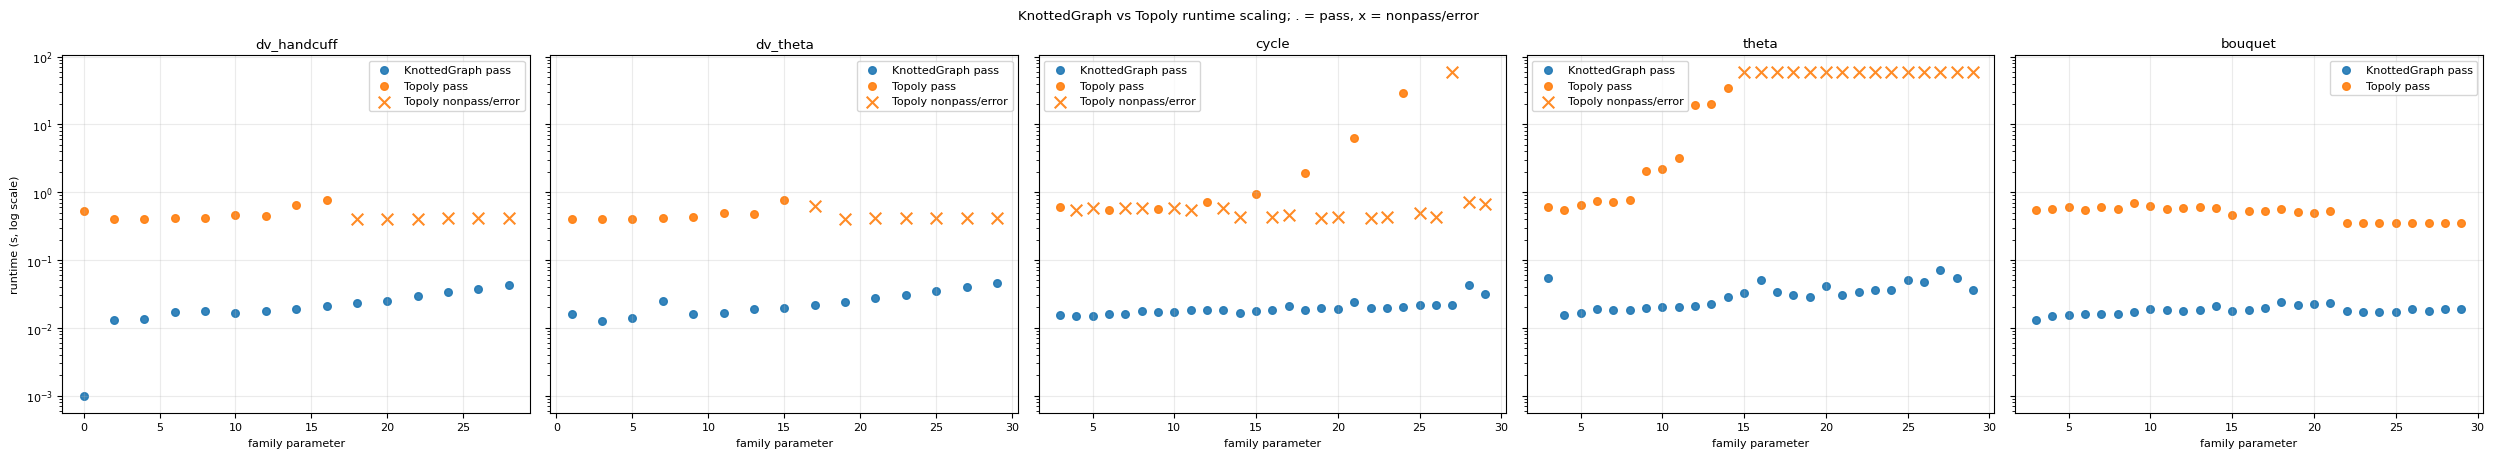

In [16]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print("matplotlib is not installed; skipping plots.")
else:
    plot_rows = list(all_result_rows) if "all_result_rows" in globals() else _read_result_csv()
    graph_order = ["dv_handcuff", "dv_theta", "cycle", "theta", "bouquet"]
    present = [graph for graph in graph_order if any(row.get("graph_type") == graph for row in plot_rows)]
    present += sorted({row.get("graph_type") for row in plot_rows if row.get("graph_type") and row.get("graph_type") not in present})

    if not present:
        print("No rows available to plot. Run the benchmark cell first.")
    else:
        fig, axes = plt.subplots(1, len(present), figsize=(5.0 * len(present), 4.6), sharey=True)
        if len(present) == 1:
            axes = [axes]

        framework_specs = [
            ("knottedgraph", "KnottedGraph", "tab:blue"),
            ("topoly", "Topoly", "tab:orange"),
        ]
        for ax, graph_type in zip(axes, present):
            rows = sorted(
                [row for row in plot_rows if row.get("graph_type") == graph_type],
                key=lambda row: (_as_float(row.get("size")) is None, _as_float(row.get("size")) or 0, str(row.get("label", ""))),
            )
            for framework, label, color in framework_specs:
                for passed, marker, suffix in [(True, ".", "pass"), (False, "x", "nonpass/error")]:
                    xs = []
                    ys = []
                    for row in rows:
                        result = row.get(f"{framework}_result") or row.get(f"{framework}_vs_published") or row.get(f"{framework}_vs_theorem")
                        y = _as_float(row.get(f"{framework}_s"))
                        x = _as_float(row.get("size"))
                        if x is None or y is None:
                            continue
                        is_pass = result == "PASS"
                        if is_pass == passed:
                            xs.append(x)
                            ys.append(y)
                    if xs:
                        ax.scatter(
                            xs,
                            ys,
                            marker=marker,
                            s=120 if marker == "." else 70,
                            color=color,
                            alpha=0.9,
                            label=f"{label} {suffix}",
                        )
            ax.set_title(graph_type)
            ax.set_xlabel("family parameter")
            ax.set_yscale("log")
            ax.grid(alpha=0.25)
            ax.legend(fontsize=8)
        axes[0].set_ylabel("runtime (s, log scale)")
        fig.suptitle("KnottedGraph vs Topoly runtime scaling; . = pass, x = nonpass/error")
        fig.tight_layout()
        plt.show()


In [17]:
current_rows = list(all_result_rows) if "all_result_rows" in globals() else _read_result_csv()
kg_nonpasses = [row for row in current_rows if _kg_result(row) != "PASS"]
topoly_nonpasses = [row for row in current_rows if _topoly_result(row) != "PASS"]

print("CSV:", RESULTS_CSV)
print("Current rows:", len(current_rows))
print("KnottedGraph nonpasses:", len(kg_nonpasses))
print("Topoly nonpasses:", len(topoly_nonpasses))

for row in kg_nonpasses:
    print("KG", row.get("case_key"), _kg_result(row), row.get("knottedgraph_error") or row.get("row_error", ""))
for row in topoly_nonpasses:
    print("Topoly", row.get("case_key"), _topoly_result(row), row.get("topoly_error") or row.get("row_error", ""))


CSV: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/results/03_knottedgraph_vs_topoly_scaling_rows.csv
Current rows: 111
KnottedGraph nonpasses: 0
Topoly nonpasses: 47
Topoly dv:theta:17 FAIL 
Topoly dv:theta:18 ERROR ValueError: Adding unsupported type.
Topoly dv:theta:19 ERROR ValueError: Adding unsupported type.
Topoly dv:theta:20 ERROR ValueError: Adding unsupported type.
Topoly dv:theta:21 ERROR ValueError: Adding unsupported type.
Topoly dv:theta:22 ERROR ValueError: Adding unsupported type.
Topoly dv:theta:23 ERROR ValueError: Adding unsupported type.
Topoly dv:theta:24 ERROR ValueError: Adding unsupported type.
Topoly dv:theta:25 ERROR ValueError: Adding unsupported type.
Topoly dv:theta:26 ERROR ValueError: Adding unsupported type.
Topoly dv:theta:27 ERROR ValueError: Adding unsupported type.
Topoly dv:theta:28 ERROR ValueError: Adding unsupported type.
Topoly dv:theta:29 ERROR Value